Epoch 1, Loss: 0.1033
Epoch 2, Loss: 0.0622
Epoch 3, Loss: 0.0633
Epoch 4, Loss: 0.0632
Epoch 5, Loss: 0.0635
Epoch 6, Loss: 0.0652
Epoch 7, Loss: 0.0632
Epoch 8, Loss: 0.0613
Epoch 9, Loss: 0.0652
Epoch 10, Loss: 0.0613
Epoch 11, Loss: 0.0618
Epoch 12, Loss: 0.0964
Epoch 13, Loss: 0.0652
Epoch 14, Loss: 0.0684
Epoch 15, Loss: 0.0624
Epoch 16, Loss: 0.0624
Epoch 17, Loss: 0.0652
Epoch 18, Loss: 0.0763
Epoch 19, Loss: 0.0652
Epoch 20, Loss: 0.0644
Epoch 21, Loss: 0.0684
Epoch 22, Loss: 0.0617
Epoch 23, Loss: 0.0622
Epoch 24, Loss: 0.0873
Epoch 25, Loss: 0.0618
Epoch 26, Loss: 0.0873
Epoch 27, Loss: 0.0618
Epoch 28, Loss: 0.0791
Epoch 29, Loss: 0.0610
Epoch 30, Loss: 0.0652
Generating Sancāra 1 | Length: 800 | Temp: 1.16
Generating Sancāra 2 | Length: 1200 | Temp: 0.61
Generating Sancāra 3 | Length: 300 | Temp: 1.13
Generating Sancāra 4 | Length: 800 | Temp: 1.19
Generating Sancāra 5 | Length: 300 | Temp: 1.08


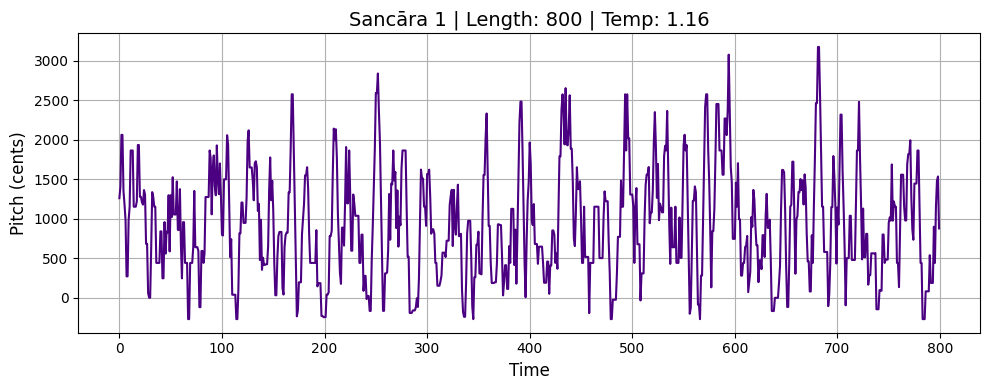

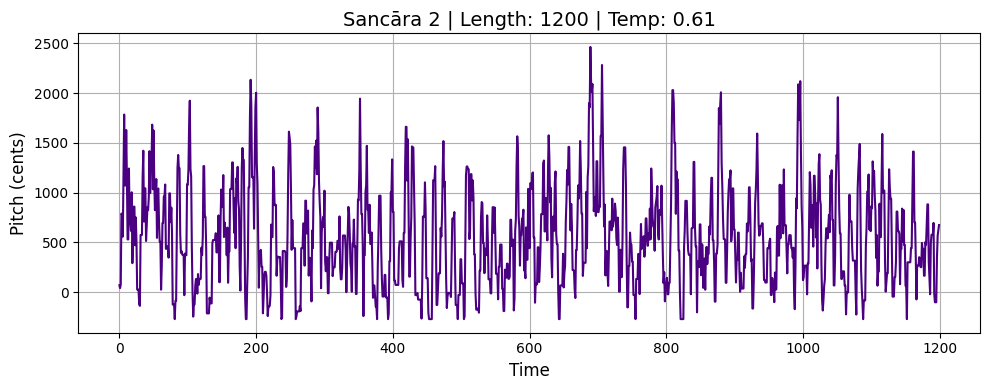

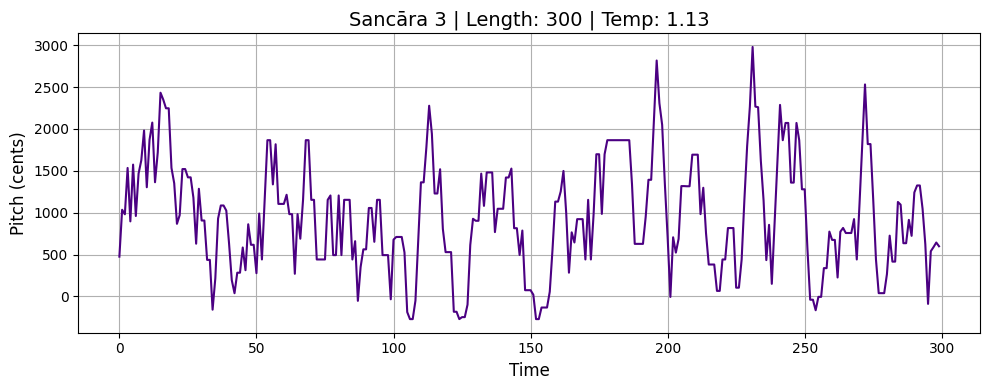

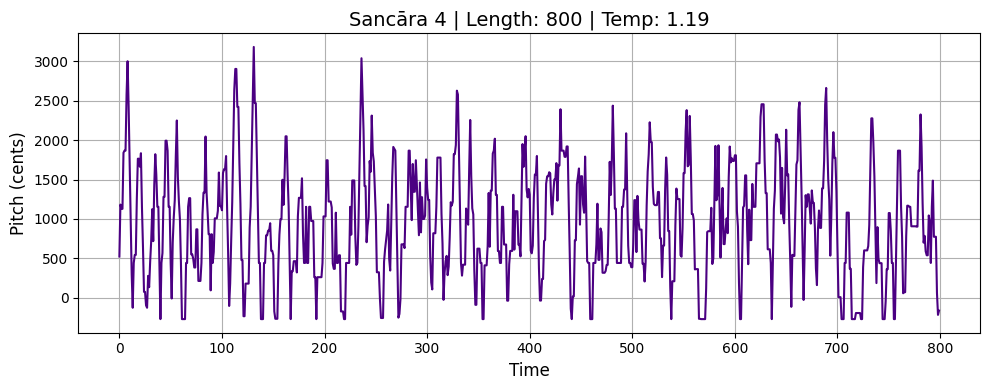

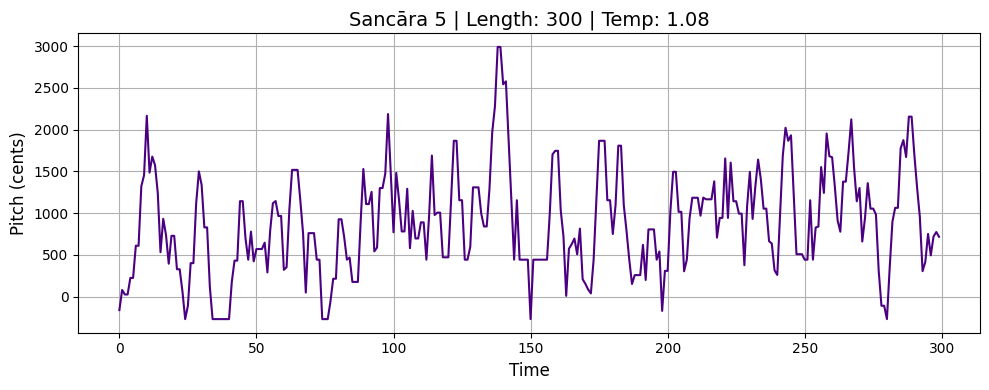

In [3]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt

# ====================== 1. Load & Normalize (Min-Max) ======================
with open("only_pitch_cents_grouped.json", "r") as file:
    raw_data = json.load(file)

phrases = [torch.tensor([p for p in seq if p != 0], dtype=torch.float32) for seq in raw_data]
lengths = [len(p) for p in phrases]
max_len = max(lengths)

all_values = torch.cat(phrases)
min_pitch = all_values.min()
max_pitch = all_values.max()

def minmax_norm(x): return (x - min_pitch) / (max_pitch - min_pitch)
def minmax_denorm(x): return x * (max_pitch - min_pitch) + min_pitch

phrases = [minmax_norm(p) for p in phrases]
padded_phrases = pad_sequence(phrases, batch_first=True, padding_value=0.0)

# ====================== 2. Add Slight Noise ======================
def add_slight_variation(tensor, noise_scale=0.05):
    return tensor + torch.randn_like(tensor) * noise_scale

# ====================== 3. Dataset ======================
class PhraseDataset(Dataset):
    def __init__(self, phrases):
        self.inputs = phrases
        self.targets = torch.stack([add_slight_variation(seq) for seq in phrases])

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

dataset = PhraseDataset(padded_phrases)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ====================== 4. Transformer with Causal Mask ======================
class PhraseTransformer(nn.Module):
    def __init__(self, seq_len, embed_dim=64, heads=4, ff_dim=128, num_layers=3):
        super().__init__()
        self.seq_len = seq_len
        self.input_proj = nn.Linear(1, embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=ff_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(embed_dim, 1)

    def forward(self, x):
        B, T = x.shape
        x = x.unsqueeze(-1)  # (B, T, 1)
        x = self.input_proj(x) + self.pos_embedding[:, :T, :]
        mask = torch.triu(torch.ones(T, T) * float('-inf'), diagonal=1).to(x.device)
        x = self.transformer(x, mask=mask)
        x = self.output_proj(x).squeeze(-1)  # (B, T)
        return torch.clamp(x, 0.0, 1.0)  # Prevent from going out of normalized range

# ====================== 5. Training ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PhraseTransformer(seq_len=max_len).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def smoothness_loss(output):
    return ((output[:, 1:] - output[:, :-1]) ** 2).mean()

model.train()
for epoch in range(30):
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y) + 0.01 * smoothness_loss(output)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

# ====================== 6. Generate Sancara ======================
def generate_sancara(model, length, start_pitch=0.0, temperature=0.8):
    model.eval()
    seq = torch.zeros(length, dtype=torch.float32).to(device)
    seq[0] = start_pitch

    with torch.no_grad():
        for i in range(1, length):
            input_seq = seq[:i].unsqueeze(0)  # shape (1, i)
            pred = model(input_seq)[0, -1]
            noise = torch.randn(1).to(device) * temperature
            seq[i] = torch.clamp(pred + noise, 0.0, 1.0)

    denorm = minmax_denorm(seq.cpu())
    return smooth(denorm)

# ====================== 7. Smooth Output ======================
def smooth(seq, w=5):
    return np.convolve(seq, np.ones(w)/w, mode='same')

# ====================== 8. Generate & Plot ======================
sancaras = []
length_choices = [300, 500, 800, 1200]

for i in range(5):
    length = np.random.choice(length_choices)
    temp = np.random.uniform(0.5, 1.2)
    print(f"Generating Sancāra {i+1} | Length: {length} | Temp: {temp:.2f}")
    sancara = generate_sancara(model, length=length, temperature=temp)
    sancaras.append((i+1, length, temp, sancara))

for idx, length, temp, sancara in sancaras:
    plt.figure(figsize=(10, 4))
    plt.plot(sancara, color='indigo')
    plt.title(f"Sancāra {idx} | Length: {length} | Temp: {temp:.2f}", fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Pitch (cents)", fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Epoch 1, Loss: 1.2288
Epoch 2, Loss: 0.2666
Epoch 3, Loss: 0.1547
Epoch 4, Loss: 0.1394
Epoch 5, Loss: 0.1006
Epoch 6, Loss: 0.0756
Epoch 7, Loss: 0.0661
Epoch 8, Loss: 0.0567
Epoch 9, Loss: 0.0514
Epoch 10, Loss: 0.0496
Generating Sancāra 1 | Length: 1200 | Temperature: 1.46
Generating Sancāra 2 | Length: 500 | Temperature: 1.01
Generating Sancāra 3 | Length: 300 | Temperature: 0.58
Generating Sancāra 4 | Length: 1500 | Temperature: 0.63
Generating Sancāra 5 | Length: 500 | Temperature: 1.08
Generating Sancāra 6 | Length: 300 | Temperature: 1.32
Generating Sancāra 7 | Length: 300 | Temperature: 0.63
Generating Sancāra 8 | Length: 1200 | Temperature: 0.91
Generating Sancāra 9 | Length: 1200 | Temperature: 0.53
Generating Sancāra 10 | Length: 1500 | Temperature: 0.67


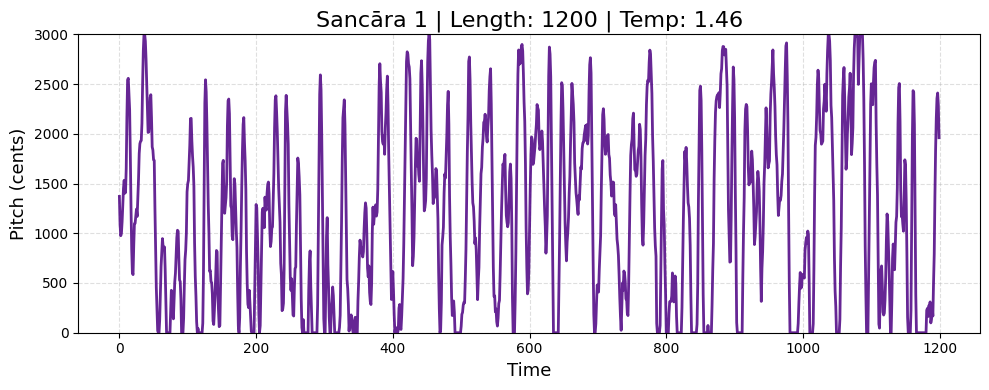

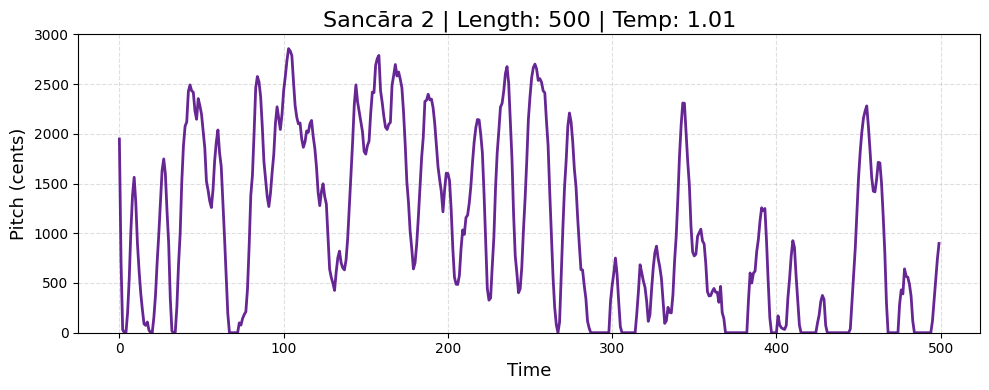

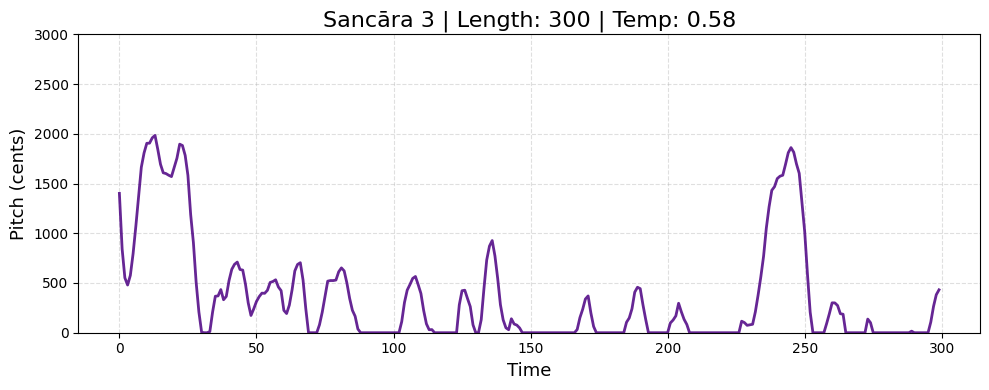

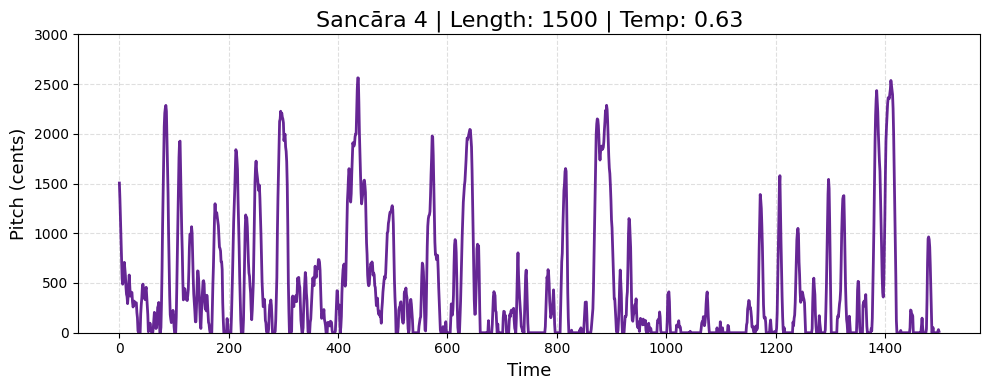

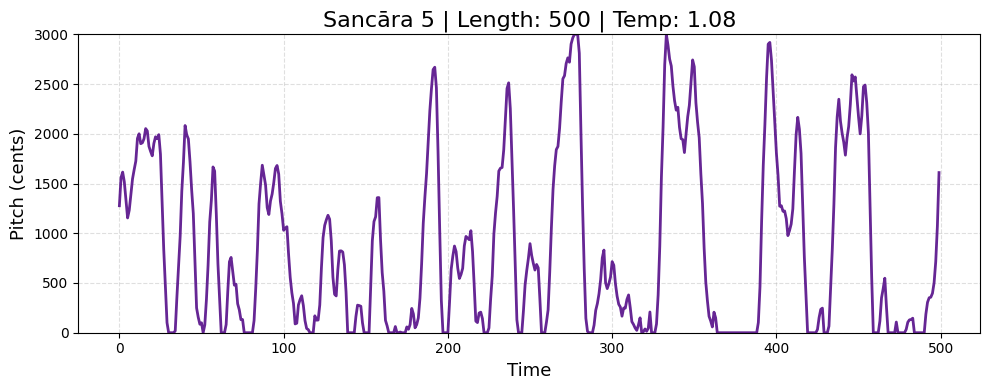

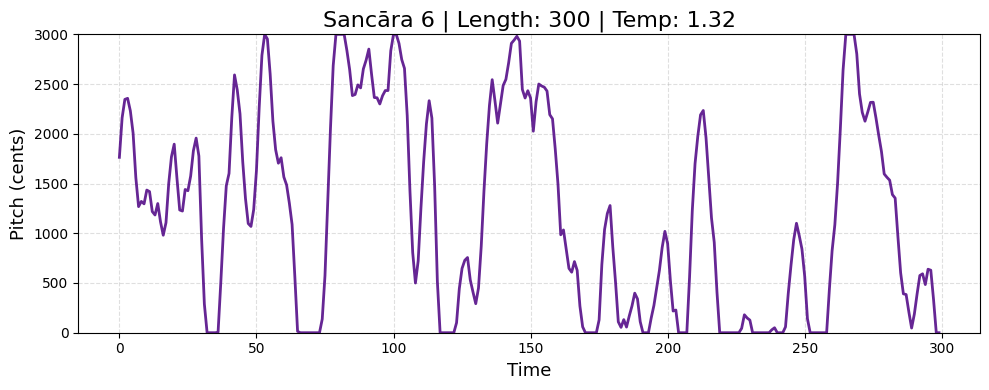

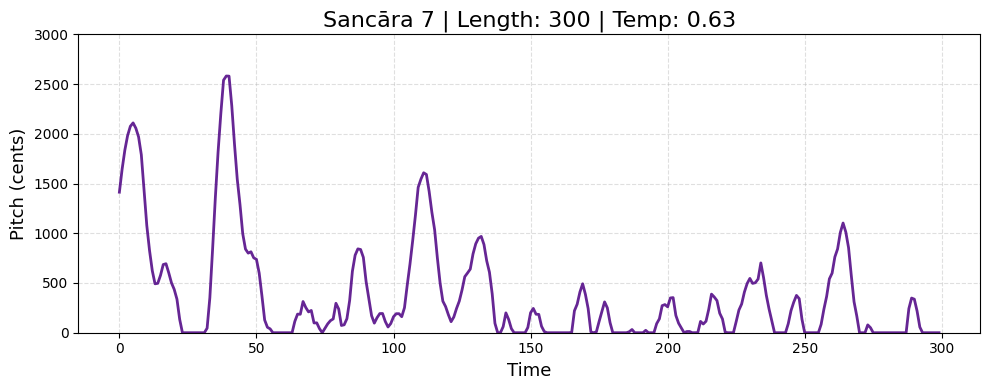

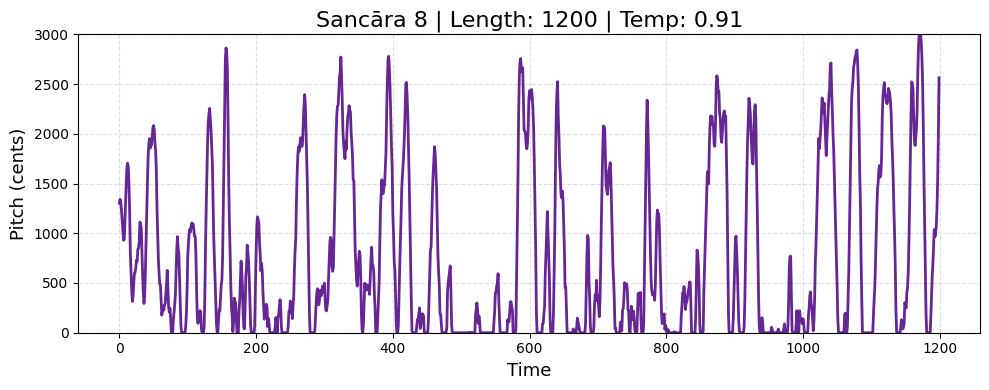

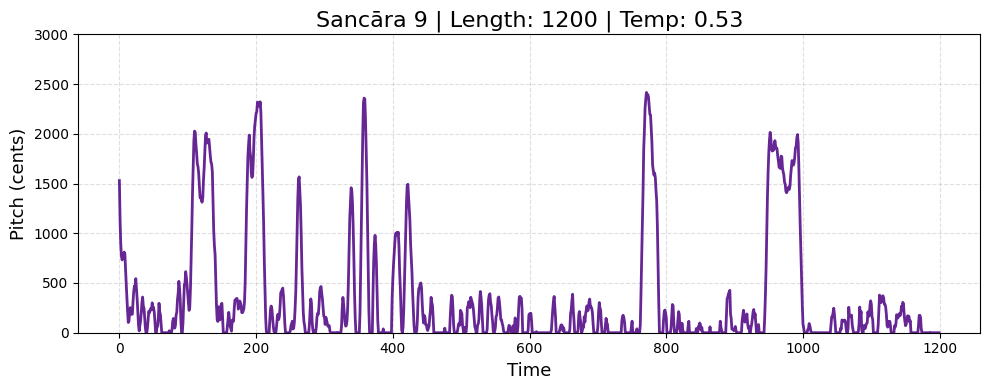

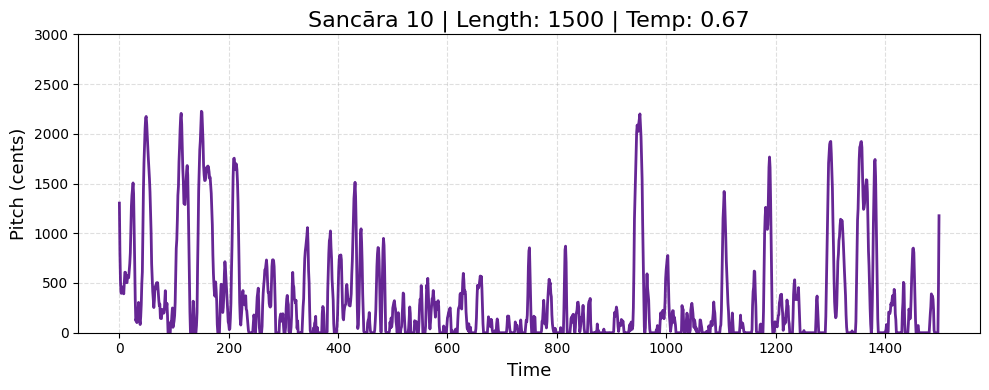

In [5]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ====================== 1. Load & Normalize Data ======================
with open("only_pitch_cents_grouped.json", "r") as file:
    raw_data = json.load(file)

phrases = [torch.tensor([p for p in seq if p != 0], dtype=torch.float32) for seq in raw_data]
lengths = [len(p) for p in phrases]
max_len = max(lengths)

padded_phrases = pad_sequence(phrases, batch_first=True, padding_value=0)
mean = padded_phrases[padded_phrases != 0].mean()
std = padded_phrases[padded_phrases != 0].std()
padded_phrases = (padded_phrases - mean) / std

# ====================== 2. Add Noise for Target ======================
def add_slight_variation(tensor, noise_scale=0.05):
    noise = torch.randn_like(tensor) * noise_scale
    return tensor + noise

# ====================== 3. Dataset Class ======================
class PhraseDataset(Dataset):
    def __init__(self, phrases):
        self.inputs = phrases
        self.targets = torch.stack([add_slight_variation(seq) for seq in phrases])

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

dataset = PhraseDataset(padded_phrases)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ====================== 4. Transformer Model ======================
class PhraseTransformer(nn.Module):
    def __init__(self, seq_len, embed_dim=64, heads=4, ff_dim=128, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(1, embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=ff_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.input_proj(x) + self.pos_embedding[:, :x.size(1), :]
        x = self.transformer(x)
        x = self.output_proj(x).squeeze(-1)
        return x

# ====================== 5. Training ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = max_len
model = PhraseTransformer(seq_len=seq_len).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(10):
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

# ====================== 6. Helper Functions ======================
def smooth(seq, window=11, polyorder=3):
    if len(seq) < window:
        return seq
    return savgol_filter(seq, window_length=window, polyorder=polyorder)

def clip_pitch_range(seq, min_val=0, max_val=3000):
    return np.clip(seq, min_val, max_val)

# ====================== 7. Generate Sancara ======================
def generate_sancara(model, length, mean, std, start_pitch=0.0, temperature=1.0):
    model.eval()
    seq = torch.zeros(length, dtype=torch.float32).to(device)
    seq[0] = start_pitch

    for i in range(1, length):
        input_seq = seq.clone().unsqueeze(0)
        with torch.no_grad():
            output = model(input_seq)[0, i - 1]
        noise = torch.randn(1).to(device) * temperature
        seq[i] = output + noise

    result = (seq.cpu() * std.item() + mean.item()).numpy()
    result = smooth(result, window=11, polyorder=3)
    result = clip_pitch_range(result, 0, 3000)
    return result

# ====================== 8. Generate and Plot ======================
sancaras = []
length_choices = [300, 500, 800, 1200, 1500]

for i in range(10):
    length = np.random.choice(length_choices)
    temperature = np.random.uniform(0.5, 1.5)
    print(f"Generating Sancāra {i+1} | Length: {length} | Temperature: {temperature:.2f}")
    sancara = generate_sancara(model, length, mean, std, temperature=temperature)
    sancaras.append((i + 1, length, temperature, sancara))

for idx, length, temp, sancara in sancaras:
    plt.figure(figsize=(10, 4))
    plt.plot(sancara, color="indigo", linewidth=2, alpha=0.85)
    plt.title(f"Sancāra {idx} | Length: {length} | Temp: {temp:.2f}", fontsize=16)
    plt.xlabel("Time", fontsize=13)
    plt.ylabel("Pitch (cents)", fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.ylim(0, 3000)
    plt.tight_layout()
    plt.show()


Epoch 1, Loss: 3.8476
Epoch 2, Loss: 2.3409
Epoch 3, Loss: 1.0140
Epoch 4, Loss: 0.8894
Epoch 5, Loss: 0.5817
Epoch 6, Loss: 0.5819
Epoch 7, Loss: 0.5095
Epoch 8, Loss: 0.4882
Epoch 9, Loss: 0.6193
Epoch 10, Loss: 0.4366
Epoch 11, Loss: 0.4328
Epoch 12, Loss: 0.5133
Epoch 13, Loss: 0.3757
Epoch 14, Loss: 0.4024
Epoch 15, Loss: 0.3033
Epoch 16, Loss: 0.2783
Epoch 17, Loss: 0.2738
Epoch 18, Loss: 0.2689
Epoch 19, Loss: 0.2305
Epoch 20, Loss: 0.2039
Epoch 21, Loss: 0.1977
Epoch 22, Loss: 0.1918
Epoch 23, Loss: 0.1734
Epoch 24, Loss: 0.1670
Epoch 25, Loss: 0.1976
Epoch 26, Loss: 0.1426
Epoch 27, Loss: 0.1704
Epoch 28, Loss: 0.1566
Epoch 29, Loss: 0.1453
Epoch 30, Loss: 0.1564
Epoch 31, Loss: 0.1434
Epoch 32, Loss: 0.1294
Epoch 33, Loss: 0.1271
Epoch 34, Loss: 0.1174
Epoch 35, Loss: 0.1187
Epoch 36, Loss: 0.1129
Epoch 37, Loss: 0.1270
Epoch 38, Loss: 0.1126
Epoch 39, Loss: 0.0994
Epoch 40, Loss: 0.1184
Epoch 41, Loss: 0.1074
Epoch 42, Loss: 0.1095
Epoch 43, Loss: 0.1017
Epoch 44, Loss: 0.08

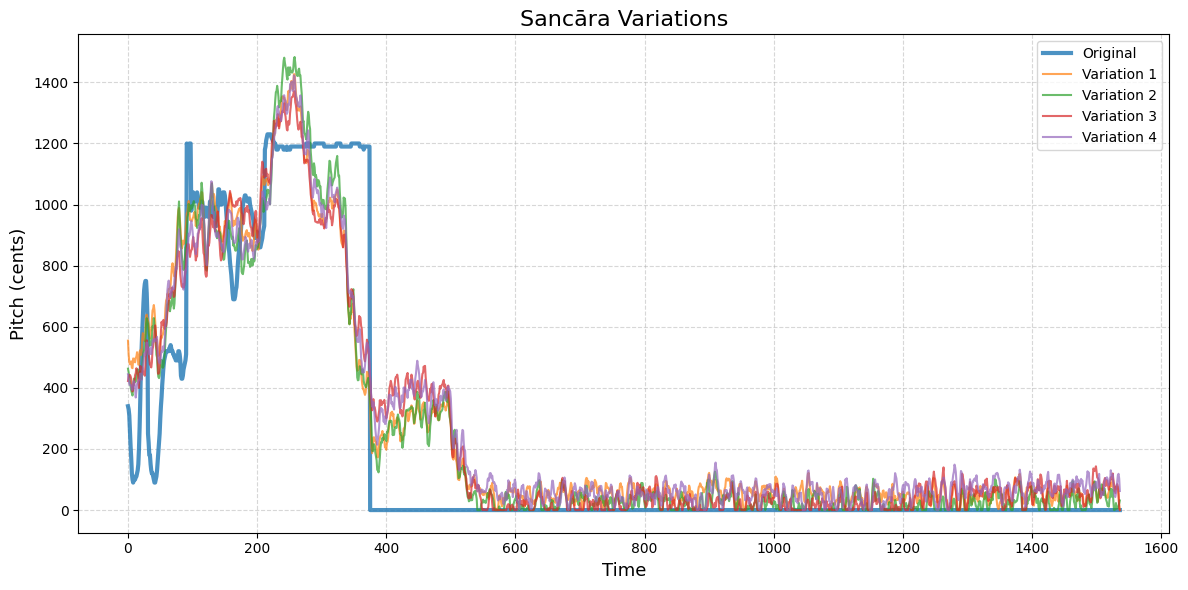

In [1]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from scipy.signal import savgol_filter

# ====================== Load and Normalize ======================
with open("/content/only_pitch_cents_grouped.json", "r") as file:
    raw_data = json.load(file)

phrases = [torch.tensor([p for p in seq if p != 0], dtype=torch.float32) for seq in raw_data]
lengths = [len(p) for p in phrases]
max_len = max(lengths)

padded_phrases = pad_sequence(phrases, batch_first=True, padding_value=0)
mean = padded_phrases[padded_phrases != 0].mean()
std = padded_phrases[padded_phrases != 0].std()
padded_phrases = (padded_phrases - mean) / std

# ====================== Dataset ======================
class PhraseDataset(Dataset):
    def __init__(self, phrases):
        self.data = phrases

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

dataset = PhraseDataset(padded_phrases)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ====================== VAE Model ======================
class VAE(nn.Module):
    def __init__(self, seq_len, hidden_dim=128, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(seq_len, hidden_dim),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, seq_len),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# ====================== Loss Function ======================
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.001 * kl_div  # Beta-VAE

# ====================== Train ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = padded_phrases.shape[1]
model = VAE(seq_len=seq_len).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(50):
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        recon, mu, logvar = model(batch)
        loss = vae_loss(recon, batch, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

# ====================== Helpers ======================
def smooth(seq, window=11, polyorder=3):
    if len(seq) < window:
        return seq
    return savgol_filter(seq, window_length=window, polyorder=polyorder)

def clip_pitch_range(seq, min_val=0, max_val=3000):
    return np.clip(seq, min_val, max_val)

# ====================== Generate Variations ======================
def generate_variation_from_phrase(model, input_tensor, num_variants=5, variation_strength=0.5):
    model.eval()
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        mu, logvar = model.encode(input_tensor.unsqueeze(0))
        variations = []
        for _ in range(num_variants):
            z = mu + variation_strength * torch.randn_like(mu)
            out = model.decode(z).squeeze(0)
            out = out.cpu().numpy() * std.item() + mean.item()
            out = smooth(out)
            out = clip_pitch_range(out)
            variations.append(out)
        return variations

# ====================== Example Visualization ======================
index = 3  # Choose one phrase
input_phrase = dataset[index]

variants = generate_variation_from_phrase(model, input_phrase, num_variants=4, variation_strength=0.4)

plt.figure(figsize=(12, 6))
plt.plot(input_phrase.numpy() * std.item() + mean.item(), label="Original", linewidth=3, alpha=0.8)
for i, var in enumerate(variants):
    plt.plot(var, label=f"Variation {i+1}", alpha=0.7)
plt.title("Sancāra Variations", fontsize=16)
plt.xlabel("Time", fontsize=13)
plt.ylabel("Pitch (cents)", fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


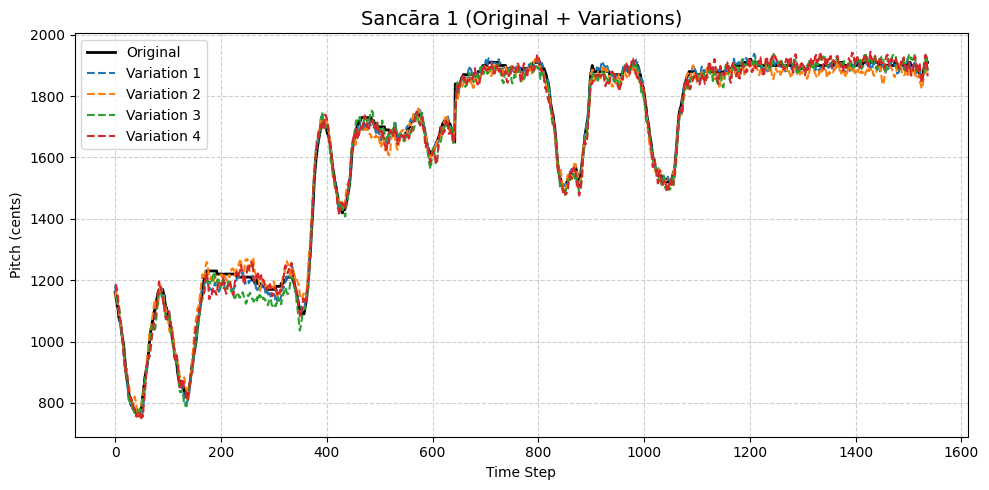

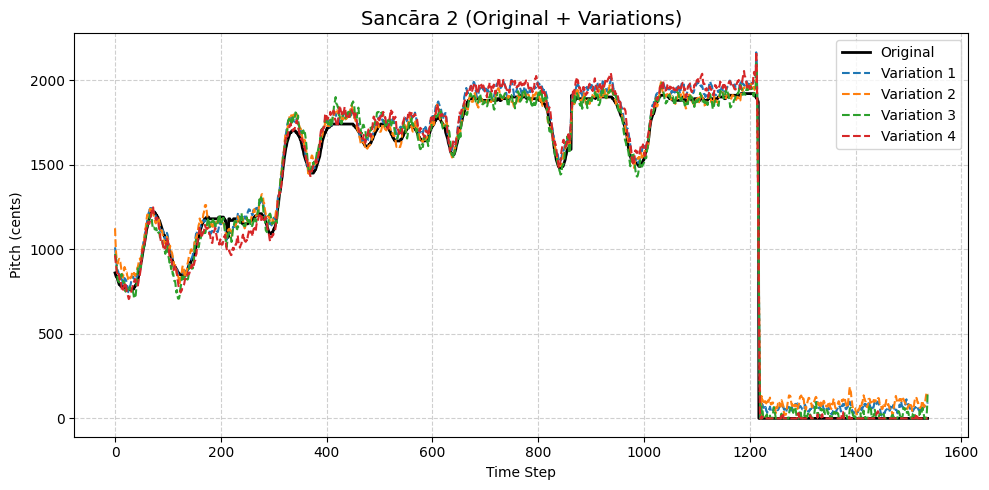

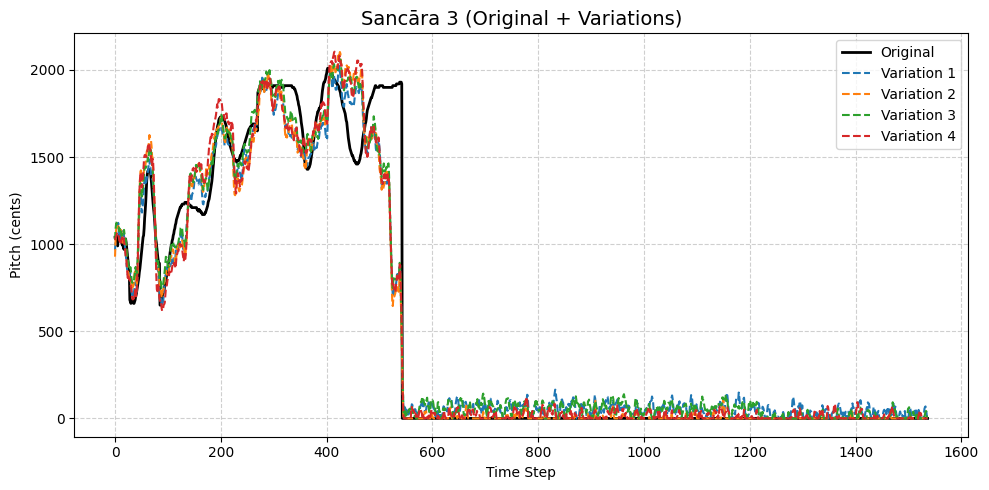

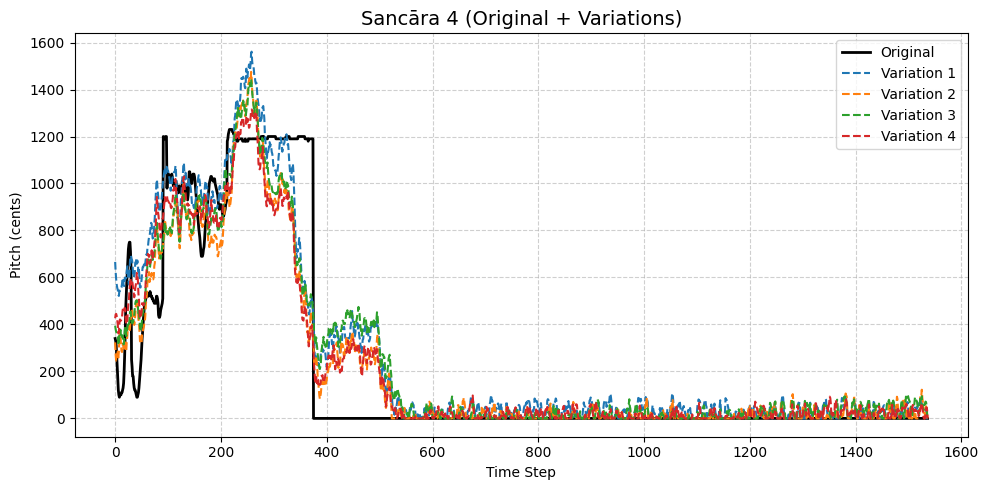

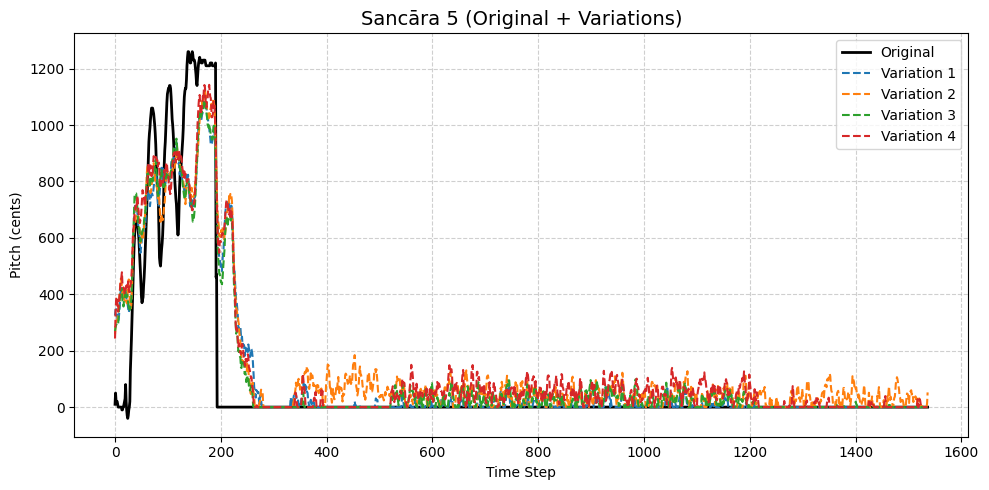

In [4]:
# ====================== Plot Each Sancāra Separately ======================
num_phrases_to_plot = 5  # Change this if you want to see more phrases

for idx in range(num_phrases_to_plot):
    input_phrase = dataset[idx]
    original = input_phrase.numpy() * std.item() + mean.item()
    variants = generate_variation_from_phrase(model, input_phrase, num_variants=4, variation_strength=0.4)

    plt.figure(figsize=(10, 5))
    plt.plot(original, label="Original", linewidth=2, color="black")
    for i, var in enumerate(variants):
        plt.plot(var, label=f"Variation {i+1}", linestyle="--")
    plt.title(f"Sancāra {idx + 1} (Original + Variations)", fontsize=14)
    plt.xlabel("Time Step")
    plt.ylabel("Pitch (cents)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


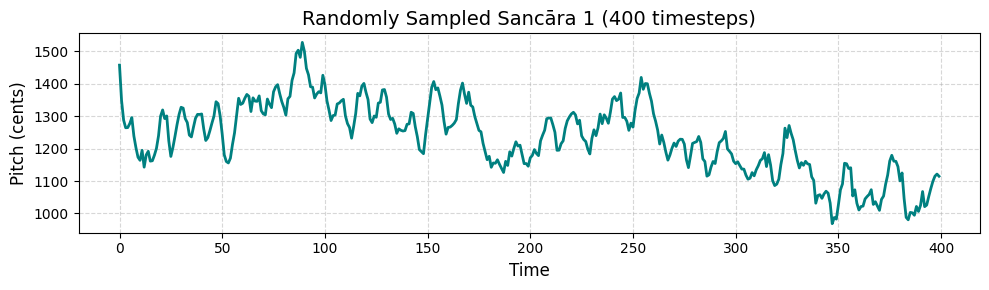

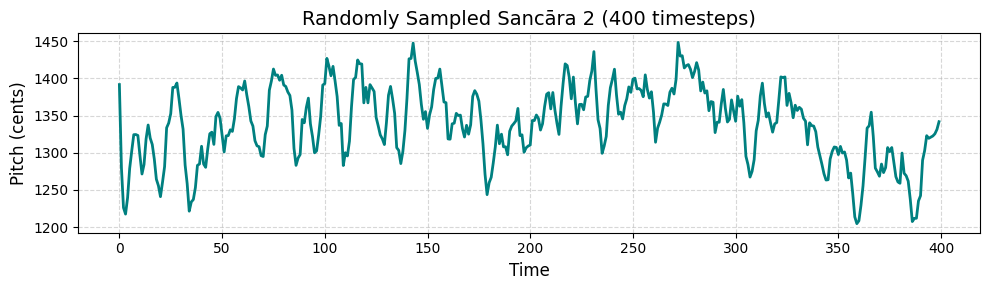

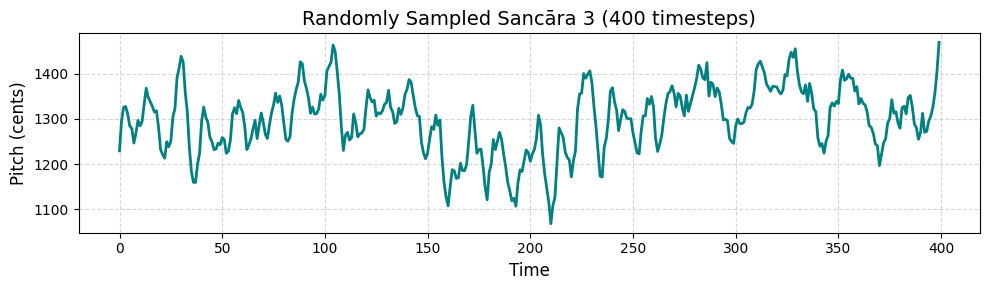

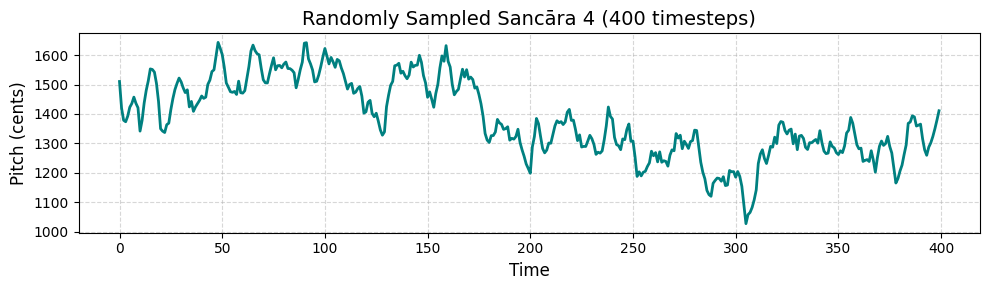

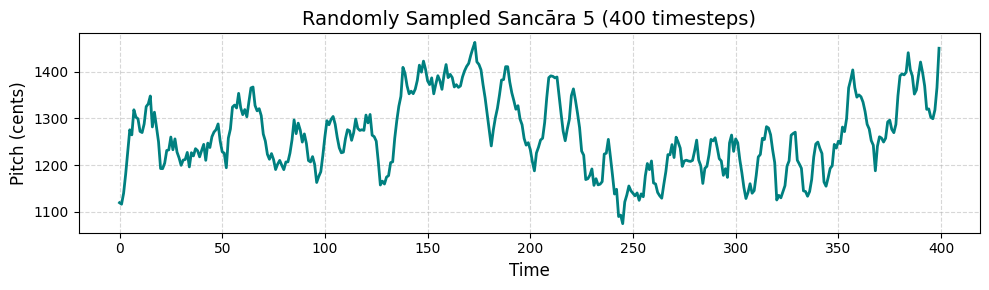

In [6]:
def generate_random_sancaras(model, num_samples=5, target_len=400):
    model.eval()
    generated = []
    with torch.no_grad():
        for _ in range(num_samples):
            z = torch.randn(1, model.mu.out_features).to(device)  # random latent vector
            out = model.decode(z).squeeze(0)                       # decoded output
            out = out[:target_len]                                 # ensure 400 timesteps
            out = out.cpu().numpy() * std.item() + mean.item()    # de-normalize
            out = smooth(out)                                     # optional smoothing
            out = clip_pitch_range(out)                           # clip values
            generated.append(out)
    return generated
random_sancaras = generate_random_sancaras(model, num_samples=5)

for i, sancara in enumerate(random_sancaras):
    plt.figure(figsize=(10, 3))
    plt.plot(sancara, linewidth=2, color='teal')
    plt.title(f"Randomly Sampled Sancāra {i+1} (400 timesteps)", fontsize=14)
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Pitch (cents)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
